# Visualization Quality Metrics: *Synthetic Data*

This notebook computes Trustworthiness, Continuity, Spearman Correlation, and DEMaP for each dimensionality reduction method (PCA, UMAP, PHATE, PaCMAP) on LLM-generated synthetic hierarchical datasets.

Embeddings and reduced embeddings are loaded from precomputed `.npy` files generated by `eval_script.py`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

# navigate to src/ from wherever the notebook is run
current = os.path.abspath('.')
while os.path.basename(current) != 'src' and current != os.path.dirname(current):
    current = os.path.dirname(current)
src_dir = current
os.chdir(src_dir)
sys.path.insert(0, src_dir)

## 1. Setup

Change the parameters here to select which synthetic dataset to evaluate. The `stem` variable is automatically built from the config. Available themes: `Energy_Ecosystems_and_Humans`, `Offshore_energy_impacts_on_fisheries`.

In [2]:
# config: change these parameters to match the synthetic dataset you want to evaluate
embedding_model  = "sentence-transformers/all-MiniLM-L6-v2"
theme            = "Energy_Ecosystems_and_Humans"  # options: Energy_Ecosystems_and_Humans, Offshore_energy_impacts_on_fisheries
t                = 1.0
max_sub          = 3 #  options: 3, 5
depth            = 5 #  options: 3, 5
synonyms         = 0
branching        = "random"
add_noise        = 0.0

# build filename stem from config
if add_noise > 0:
    stem = f"{theme}_hierarchy_t{t}_maxsub{max_sub}_depth{depth}_synonyms{synonyms}_noise{add_noise}_{branching}"
else:
    stem = f"{theme}_hierarchy_t{t}_maxsub{max_sub}_depth{depth}_synonyms{synonyms}_{branching}"

embedding_dir = f"intermediate_data/{embedding_model}_embeddings"
reduction_dir = f"intermediate_data/{embedding_model}_reduced_embeddings"
results_dir   = f"intermediate_data/{embedding_model}_results"
os.makedirs(results_dir, exist_ok=True)

print(f"Stem: {stem}")
print(f"Embedding dir: {embedding_dir}")
print(f"Reduction dir: {reduction_dir}")
print(f"Results dir:   {results_dir}")

Stem: Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_random
Embedding dir: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_embeddings
Reduction dir: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_embeddings
Results dir:   intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results


## 2. Load Embeddings

Load precomputed embeddings from `eval_script.py` output. To generate these, run:

```bash
python src/run_models/synthetic_data/eval_script.py --theme Energy_Ecosystems_and_Humans --t 1.0 --max_sub 3 --depth 5 --synonyms 0 --branching random
```

In [3]:
# load precomputed high-dimensional embeddings
embed_path = f"{embedding_dir}/{stem}_embed.npy"
x_high = np.load(embed_path)
print(f"Embeddings shape: {x_high.shape}")

Embeddings shape: (1600, 384)


In [4]:
# load precomputed reduced embeddings from eval_script.py
reductions = {
    "PCA":    np.load(f"{reduction_dir}/PCA_{stem}_embed.npy"),
    "UMAP":   np.load(f"{reduction_dir}/UMAP_{stem}_embed.npy"),
    "PHATE":  np.load(f"{reduction_dir}/PHATE_{stem}_embed.npy"),
    "PaCMAP": np.load(f"{reduction_dir}/PaCMAP_{stem}_embed.npy"),
}

for name, arr in reductions.items():
    print(f"{name}: {arr.shape}")

PCA: (1600, 300)
UMAP: (1600, 300)
PHATE: (1600, 300)
PaCMAP: (1600, 100)


**Note:** PaCMAP was precomputed at 100 dims while PCA, UMAP, and PHATE are at 300 dims. This does not affect the visualization metrics since all metrics use only the first 2 dimensions

## 3. Metrics

- **Trustworthiness**: measures whether neighbors in low-dim space were also neighbors in high-dim space (local structure preservation)
- **Continuity**: measures whether neighbors in high-dim space are preserved in low-dim space (reverse of trustworthiness)
- **Spearman Correlation**: rank correlation of raw pairwise Euclidean distances high-dim vs 2D
- **DEMaP** (Moon et al. 2019): Spearman correlation of geodesic distances (k-NN shortest paths) in high-dim vs Euclidean distances in 2D

Trustworthiness and Continuity range from 0 to 1, higher is better. Spearman and DEMaP range from -1 to 1, where 1 is perfect preservation and 0 means no relationship. Scores near 0.5 (T/C) or near 0 (Spearman/DEMaP) are expected even on synthetic data due to the 384 to 2 compression.

The synthetic datasets have explicit hierarchical structure, so higher DEMaP scores are expected on shallow hierarchies (depth3). Deeper hierarchies (depth5) create finer distinctions that may not survive compression to 2D, so scores there may be closer to 0.

In [5]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    n = x_high.shape[0]

    d_high = pairwise_distances(x_high)
    d_low  = pairwise_distances(x_low)
    rank_low = np.argsort(np.argsort(d_low, axis=1), axis=1)

    continuity = 0.0
    for i in range(n):
        neighbors_high = set(np.argsort(d_high[i])[1:n_neighbors+1])
        neighbors_low  = set(np.argsort(d_low[i])[1:n_neighbors+1])
        missing = neighbors_high - neighbors_low
        for j in missing:
            continuity += rank_low[i, j] - n_neighbors

    norm = 2.0 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))
    return 1 - norm * continuity

In [6]:
def compute_demap(x_high, x_low_2d, n_neighbors=5):
    # DEMaP: geodesic distances (k-NN shortest path) in high-dim vs Euclidean in 2D
    # Moon et al. 2019 (PHATE paper), k=5 to emphasize local structure
    knn = kneighbors_graph(x_high, n_neighbors=n_neighbors, mode='distance', include_self=False)
    geo = shortest_path(knn, directed=False)

    # replace inf (disconnected pairs) with 1 + max finite distance
    # treats disconnected pairs as maximally far rather than dropping them
    max_finite = np.nanmax(geo[np.isfinite(geo)])
    geo[np.isinf(geo)] = 1 + max_finite

    idx = np.triu_indices(x_high.shape[0], k=1)
    geo_flat = geo[idx]
    euc_flat = pairwise_distances(x_low_2d)[idx]

    return spearmanr(geo_flat, euc_flat)[0]

In [7]:
stats = []

# subsample for large datasets to avoid memory issues (pairwise distances scale as n^2)
# all synthetic datasets in this project are under 2293 points so no subsampling occurs 
max_samples = 5000 #kept for larger synthetic dataset (in the future potentially)
if x_high.shape[0] > max_samples:
    np.random.seed(42)
    idx = np.random.choice(x_high.shape[0], max_samples, replace=False)
    x_high_sub = x_high[idx]
    reductions_sub = {name: arr[idx] for name, arr in reductions.items()}
    print(f"Subsampled to {max_samples} points for metrics computation")
else:
    x_high_sub = x_high
    reductions_sub = reductions
    print(f"No subsampling needed ({x_high.shape[0]} points, threshold={max_samples})")

for name, x_low in reductions_sub.items():
    # use first 2 dimensions for metrics (methods have varying n_components)
    x_low_2d = x_low[:, :2] if x_low.ndim > 1 and x_low.shape[1] > 2 else x_low

    t_score = trustworthiness(x_high_sub, x_low_2d, n_neighbors=15)
    c_score = compute_continuity(x_high_sub, x_low_2d, n_neighbors=15)

    # spearman correlation of raw pairwise Euclidean distances
    d_high = pairwise_distances(x_high_sub).flatten()
    d_low  = pairwise_distances(x_low_2d).flatten()
    spearman_corr, _ = spearmanr(d_high, d_low)

    # DEMaP: geodesic distances in high-dim vs Euclidean in 2D (Moon et al. 2019)
    # k=5 for local structure, inf replaced with 1+max distance
    print(f"  Computing DEMaP for {name}...")
    demap_score = compute_demap(x_high_sub, x_low_2d, n_neighbors=5)

    stats.append({
        "Method": name,
        "Trustworthiness": round(t_score, 4),
        "Continuity": round(c_score, 4),
        "Spearman Correlation": round(spearman_corr, 4),
        "DEMaP": round(demap_score, 4)
    })
    print(f"{name}: Trustworthiness={t_score:.4f}, Continuity={c_score:.4f}, Spearman={spearman_corr:.4f}, DEMaP={demap_score:.4f}")

pd.DataFrame(stats)

No subsampling needed (1600 points, threshold=5000)
  Computing DEMaP for PCA...
PCA: Trustworthiness=0.5013, Continuity=0.5012, Spearman=0.0062, DEMaP=-0.0004
  Computing DEMaP for UMAP...
UMAP: Trustworthiness=0.5017, Continuity=0.4997, Spearman=0.0002, DEMaP=0.0042
  Computing DEMaP for PHATE...
PHATE: Trustworthiness=0.5019, Continuity=0.5014, Spearman=0.0043, DEMaP=0.0028
  Computing DEMaP for PaCMAP...
PaCMAP: Trustworthiness=0.4993, Continuity=0.5032, Spearman=0.0013, DEMaP=0.0003


,Method,Trustworthiness,Continuity,Spearman Correlation,DEMaP
0,PCA,0.5013,0.5012,0.0062,-0.0004
1,UMAP,0.5017,0.4997,0.0002,0.0042
2,PHATE,0.5019,0.5014,0.0043,0.0028
3,PaCMAP,0.4993,0.5032,0.0013,0.0003


In [8]:
output_path = os.path.join(results_dir, f"viz_metrics_{stem}.csv")
pd.DataFrame(stats).to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/viz_metrics_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_random.csv


## 4. Shepard Diagrams

Compares pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

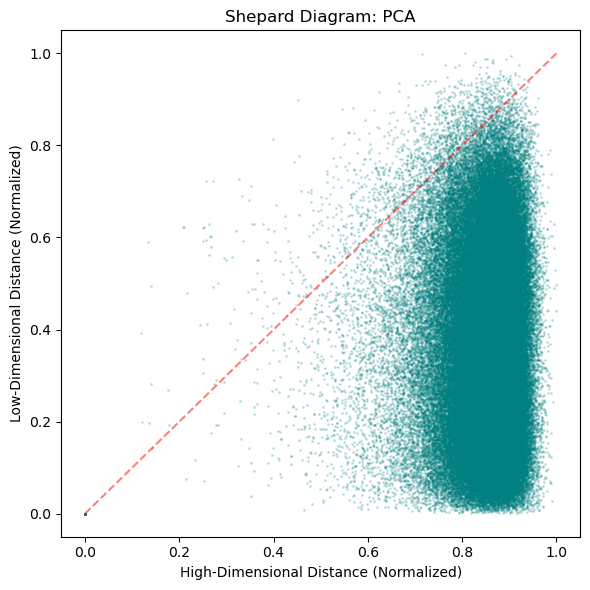

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_random_pca.png


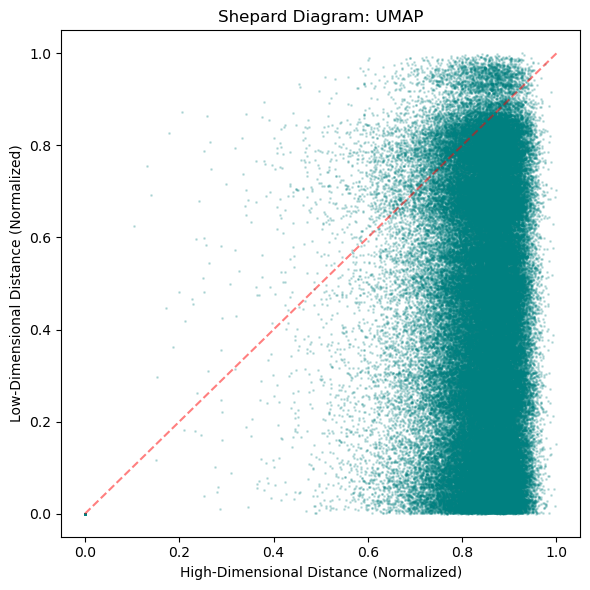

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_random_umap.png


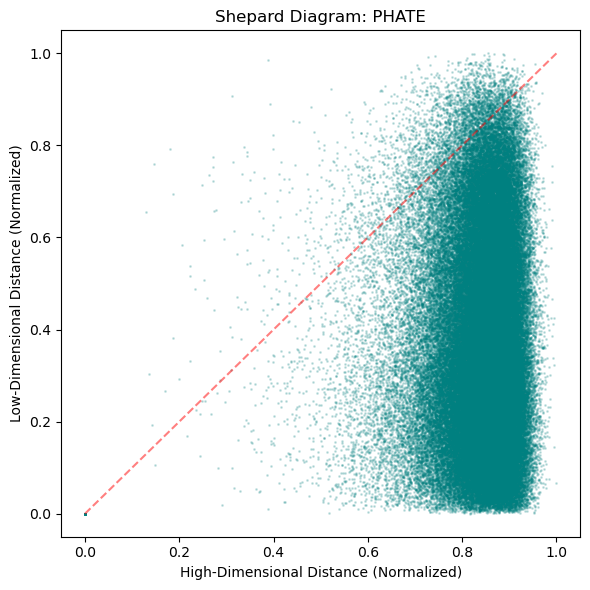

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_random_phate.png


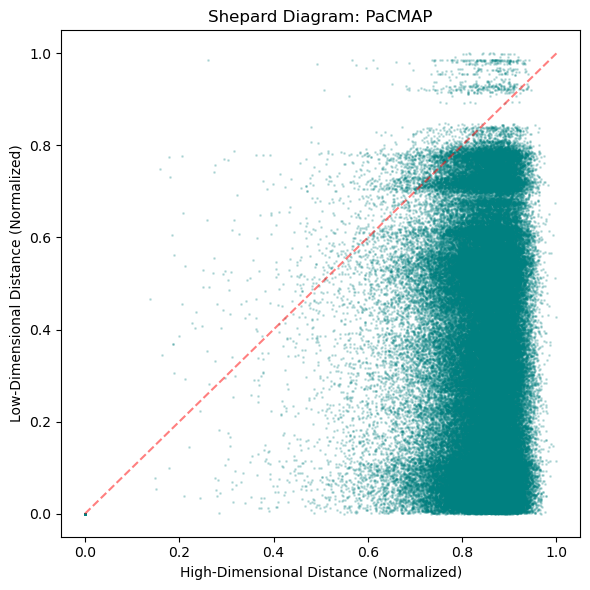

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_random_pacmap.png


In [9]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), sample_size, replace=False)

    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low  = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low  = d_low  / np.max(d_low)

    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()

    filename = os.path.join(results_dir, f"shepard_{stem}_{name.lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

for name, x_low in reductions.items():
    x_low_2d = x_low[:, :2] if x_low.ndim > 1 and x_low.shape[1] > 2 else x_low
    f = plot_shepard(x_high, x_low_2d, name)
    print(f"Saved: {f}")

## 5. Results

Results across all four synthetic datasets using `all-MiniLM-L6-v2` embeddings projected to 2D. DEMaP uses k=5 neighbors; disconnected pairs are set to 1+max finite distance.

**Energy Ecosystems and Humans: maxsub5, depth3 (832 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.5043 | 0.5124 | 0.0246 | -0.0030 |
| UMAP | 0.5067 | 0.5074 | 0.0152 | 0.0020 |
| PHATE | 0.5080 | 0.5081 | 0.0350 | 0.0049 |
| PaCMAP | 0.5052 | 0.5060 | 0.0110 | -0.0002 |

**Energy Ecosystems and Humans: maxsub3, depth5 (1600 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.5013 | 0.5012 | 0.0062 | -0.0004 |
| UMAP | 0.5017 | 0.4997 | 0.0002 | 0.0042 |
| PHATE | 0.5019 | 0.5014 | 0.0043 | 0.0028 |
| PaCMAP | 0.4993 | 0.5032 | 0.0013 | 0.0003 |

**Offshore Energy Impacts on Fisheries: maxsub5, depth3 (745 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.4968 | 0.5033 | 0.0139 | 0.0125 |
| UMAP | 0.5018 | 0.5031 | 0.0166 | 0.0213 |
| PHATE | 0.5035 | 0.5059 | 0.0298 | 0.0398 |
| PaCMAP | 0.5088 | 0.5023 | 0.0183 | 0.0215 |

**Offshore Energy Impacts on Fisheries: maxsub3, depth5 (2293 documents)**

| Method | Trustworthiness | Continuity | Spearman | DEMaP |
|--------|----------------|------------|----------|-------|
| PCA | 0.5015 | 0.5001 | -0.0088 | -0.0068 |
| UMAP | 0.5016 | 0.5009 | -0.0073 | -0.0062 |
| PHATE | 0.4993 | 0.5015 | -0.0105 | -0.0090 |
| PaCMAP | 0.5021 | 0.5018 | -0.0098 | -0.0053 |

## 6. Discussion

**Shallow hierarchies (depth3) outperformed deep hierarchies (depth5) across both themes.** The maxsub5_depth3 configs produced consistently positive DEMaP and Spearman scores while maxsub3_depth5 produced scores near or at 0. A shallower hierarchy with more branching may produce embeddings that are easier to lay out in 2D, while deeper hierarchies create finer-grained distinctions that get lost in the compression.

**Offshore_energy maxsub5_depth3 had the highest DEMaP scores of any dataset** (including all benchmark datasets), with PHATE reaching 0.0398. This suggests that for some synthetic topic configurations, the hierarchical structure is partially recoverable in 2D. PHATE consistently led on this dataset across both Spearman and DEMaP, which is consistent with PHATE being designed to preserve manifold structure.

**Spearman and DEMaP mostly agree in direction** datasets where DEMaP is positive also have positive Spearman, and the one dataset with negative Spearman (Offshore depth5) also has negative DEMaP. The main difference is that Spearman captures raw Euclidean distance preservation while DEMaP captures geodesic (manifold) structure. PHATE leading on DEMaP more than on Spearman suggests it does better at preserving the curved manifold geometry than raw distances.

**Trustworthiness and Continuity again showed almost no differentiation** across methods or datasets, confirming that these local metrics are not sensitive enough to distinguish between methods when compressing to 2D. DEMaP is the more informative metric for this task.

**Synthetic datasets showed higher DEMaP scores than benchmark datasets** on the shallow hierarchy configs. This is expected since the synthetic data was generated with an explicit hierarchical structure, so there is more geometric organization to preserve. The benchmark datasets contain real-world text with no enforced structure.

## Next Steps: Noise Extension

To further evaluate how well each DR method preserves hierarchical structure, I plan to rerun the full pipeline on noisy versions of the same 4 synthetic datasets at two noise levels: 25% and 50%. This will give a controlled comparison across clean, slightly noisy, and more heavily noisy data.

The data generation pipeline already supports noise via the `add_noise` parameter. To generate noisy datasets, update `add_noise` in `run_all.sh` (or pass it directly to `generate.py`) and rerun `eval_script.py` to get the corresponding embeddings and reduced embeddings. Then run this notebook with `add_noise=0.25` or `add_noise=0.5` in the config cell.

Higher noise should lower DEMaP scores since the hierarchical structure becomes harder to preserve. If scores stay relatively stable across noise levels, that would suggest the DR methods are not sensitive to this type of structural degradation.